<a href="https://colab.research.google.com/github/ashishsingh752/SolarEnergyPredictionUsingML/blob/main/solar_energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


**Load Data Set**

In [12]:
# Load the dataset
df = pd.read_csv('/content/SolarDataSet.csv')


In [13]:
# Constants
Gstc = 1  # kW/m² (STC solar radiation)
Tstc = 25  # °C (STC temperature)
Ct = -0.0025  # Temperature coefficient for a-Si (as an example)
Fpv = 0.879  # Derating factor
NOCT = 45  # Nominal Operating Cell Temperature in °C
rho = 1.225  # Air density in kg/m³
A = 3  # Swept area in m² for wind turbine

In [14]:
# Check for necessary columns and simulate if missing
if 'Ga' not in df.columns:
    df['Ga'] = np.random.uniform(0.8, 1.2, size=len(df))  # Simulate global solar radiation


In [15]:
# Calculate Tc using the given formula
df['Tc'] = df['AmbientTemp'] + ((NOCT - 20) * df['Ga']) / Fpv

# Feature Engineering for Solar
df['Ga/Gstc'] = df['Ga'] / Gstc
df['(Tc-Tstc)'] = df['Tc'] - Tstc
df['Temp_Correction'] = Fpv * (1 + df['(Tc-Tstc)'] * Ct)

# Calculate PV output power (Ppv)
df['Ppv'] = df['Ga/Gstc'] * df['Temp_Correction'] * df['PolyPwr']

# Calculate wind power using the formula
df['Calculated_Wind_Power_W'] = 0.5 * rho * A * (df['Wind.Speed'] ** 3)
df['Calculated_Wind_Power_kW'] = df['Calculated_Wind_Power_W'] / 1000

In [16]:
# Define features and target variables
X = df[['Latitude', 'Longitude', 'Altitude', 'Humidity', 'AmbientTemp', 'Wind.Speed', 'Visibility', 'Pressure', 'Cloud.Ceiling', 'Month', 'Hour', 'Season']]
y_solar = df['Ppv']
y_wind = df['Calculated_Wind_Power_kW']

In [17]:
# Convert categorical variables to numerical (One-Hot Encoding)
X = pd.get_dummies(X, columns=['Season', 'Month'], drop_first=True)

In [18]:
# Train-Test Split
X_train, X_test, y_solar_train, y_solar_test = train_test_split(X, y_solar, test_size=0.2, random_state=42)
X_train, X_test, y_wind_train, y_wind_test = train_test_split(X, y_wind, test_size=0.2, random_state=42)

In [19]:
# Initialize the models
model_solar = RandomForestRegressor(n_estimators=100, random_state=42)
model_wind = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the models
model_solar.fit(X_train, y_solar_train)
model_wind.fit(X_train, y_wind_train)

RandomForestRegressor(random_state=42)

In [20]:
# Make predictions
solar_pred = model_solar.predict(X_test)
wind_pred = model_wind.predict(X_test)

# Evaluate the models
solar_rmse = np.sqrt(mean_squared_error(y_solar_test, solar_pred))
solar_r2 = r2_score(y_solar_test, solar_pred)

wind_rmse = np.sqrt(mean_squared_error(y_wind_test, wind_pred))
wind_r2 = r2_score(y_wind_test, wind_pred)

# Print evaluation results
print(f"Solar Model - RMSE: {solar_rmse}, R²: {solar_r2}")
print(f"Wind Model - RMSE: {wind_rmse}, R²: {wind_r2}")

Solar Model - RMSE: 3.564217361517465, R²: 0.6131091993283753
Wind Model - RMSE: 1.312719838414294, R²: 0.9789842253955343


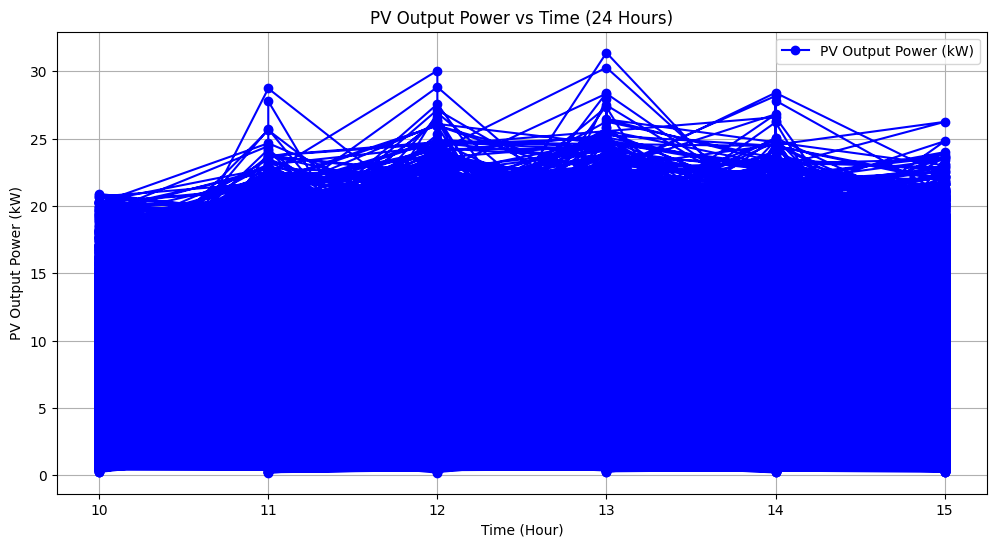

In [29]:
# Plot the solar power output
plt.figure(figsize=(12, 6))
plt.plot(df['Hour'], df['Ppv'], label='PV Output Power (kW)', color='blue', marker='o')
plt.xlabel('Time (Hour)')
plt.ylabel('PV Output Power (kW)')
plt.title('PV Output Power vs Time (24 Hours)')
plt.grid(True)
# plt.xticks(range(24))
plt.legend()
plt.show()

In [30]:
# Plot the wind power output
plt.figure(figsize=(12, 6))
plt.plot(df['Hour'], df['Calculated_Wind_Power_kW'], label='Wind Power Output (kW)', color='orange', marker='o')
plt.xlabel('Time (Hour)')
plt.ylabel('Wind Power Output (kW)')
plt.title('Wind Power Output vs Time (24 Hours)')
plt.grid(True)
# plt.xticks(range(24))
plt.legend()
plt.show()


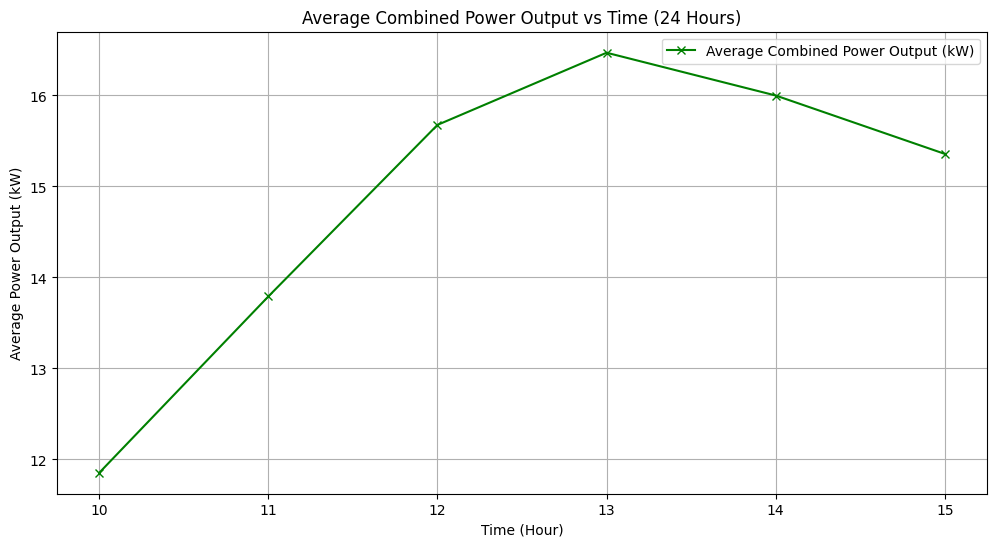

In [31]:
# Calculate average power output for both solar and wind
df['Total_Power_kW'] = df['Ppv'] + df['Calculated_Wind_Power_kW']
avg_power_per_hour = df.groupby('Hour')['Total_Power_kW'].mean().reset_index()

# Plot the combined average power output vs. time
plt.figure(figsize=(12, 6))
plt.plot(avg_power_per_hour['Hour'], avg_power_per_hour['Total_Power_kW'], label='Average Combined Power Output (kW)', color='green', marker='x')
plt.xlabel('Time (Hour)')
plt.ylabel('Average Power Output (kW)')
plt.title('Average Combined Power Output vs Time (24 Hours)')
plt.grid(True)
plt.legend()
# plt.xticks(range(24))
plt.show()